# Initialization

In [1]:
import stim
import itertools
import logging
import random
import pandas as pd
import os



from concurrent.futures import ProcessPoolExecutor

from wrappers.polar_wrapper import (
    polar_code_p2, get_logical_error_on_accepted_states, divide_half_list
)
from wrappers.stim_wrapper import (
    calculate_logical_error_result_polar,
    simulate_batch_and_save_result_polar,
    generate_qiskit_polar_code, compiled_to_qiskit_hardware,
    get_backend_information, convert_i_to_meas_type,
    generate_circuit_extraction_syndrome_stim_normal, 
    create_circuit_polar_stim_normal,
    simulate_stim_polar_code_normal
)

from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit.transpiler import Layout
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error
import copy 


# Stim Simulation Normal

## Toy Example

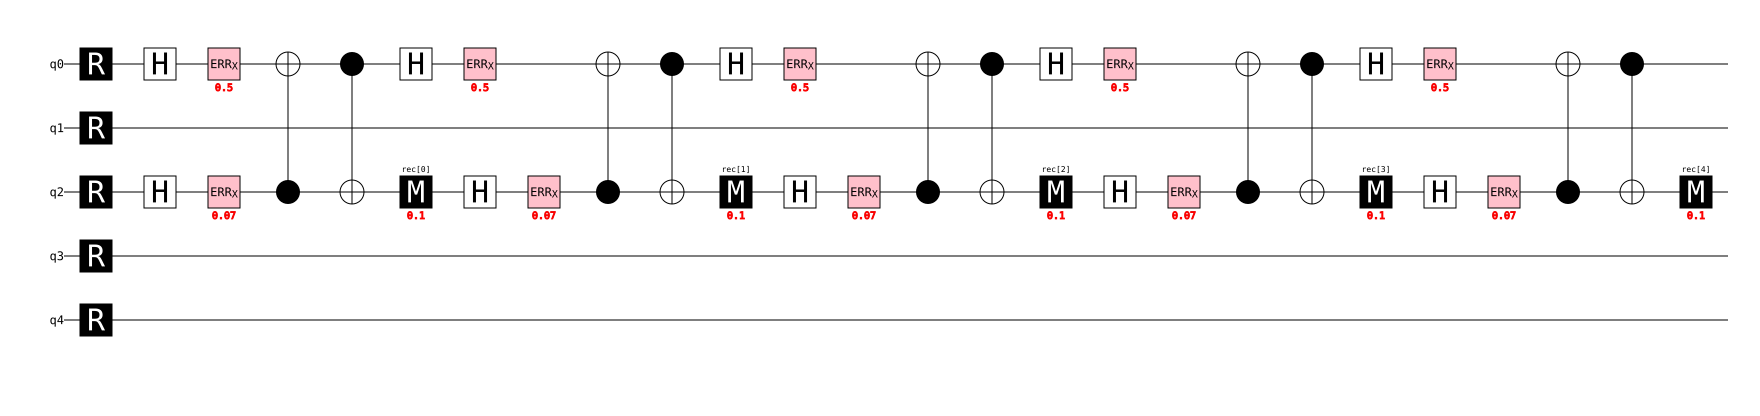

In [2]:
# manual polar_n3_x
circuit = stim.Circuit()

# First, the circuit will initialize a Bell pair.
circuit.append("R", range(0,5))

for i in range(5):

    circuit.append("H", [0,2])
    circuit.append("X_ERROR", [0], [0.5] )
    circuit.append("X_ERROR", [2], [0.07] )
    # noisy_circuit.append("X_ERROR", ins.targets_copy(), p_error)
    # circuit.append("H", [5])
    circuit.append("CNOT", [2, 0])
    circuit.append("CNOT", [0, 2],)
    circuit.append("MZ", [2], 0.1)
    # circuit.append("M", [0, 2])




circuit.diagram("timeline-svg")


### Noiseless

In [3]:
# manual polar_n3_x
circuit = stim.Circuit()

# First, the circuit will initialize a Bell pair.
circuit.append("R", range(0,12))

circuit.append("H", [2,5,8,11])
circuit.append("CNOT", [2, 0, 5, 3, 8, 6, 11, 9])
circuit.append("CNOT", [2, 1, 5, 4, 8, 7, 11, 10])
circuit.append("H", [2,5,8,11])
circuit.append("M", [2,5,8,11])

circuit.append("R", [2,5,8,11])
circuit.append("CNOT", [0, 2, 1, 5, 6, 8, 7, 11])
circuit.append("CNOT", [3, 2, 4, 5, 9, 8, 10, 11])
circuit.append("M", [2,5,8,11])

circuit.append("R", [2,5,8,11])
circuit.append("H", [2,5,8,11])
circuit.append("CNOT", [2, 0, 5, 1, 8, 3, 11, 4])
circuit.append("CNOT", [2, 6, 5, 7, 8, 9, 11, 10])
circuit.append("H", [2,5,8,11])
circuit.append("M", [2,5,8,11])

circuit.append("H", [0,1,3,4,6,7,9,10])
circuit.append("M", [0,1,3,4,6,7,9,10])


In [4]:
data = [2, 0, 5, 3, 8, 6, 11, 9]

# Zip the list with a slice of itself starting from the second element
for x1, x2 in zip(data[::2], data[1::2]):
    print(f"x1 = {x1}, x2 = {x2}")

x1 = 2, x2 = 0
x1 = 5, x2 = 3
x1 = 8, x2 = 6
x1 = 11, x2 = 9


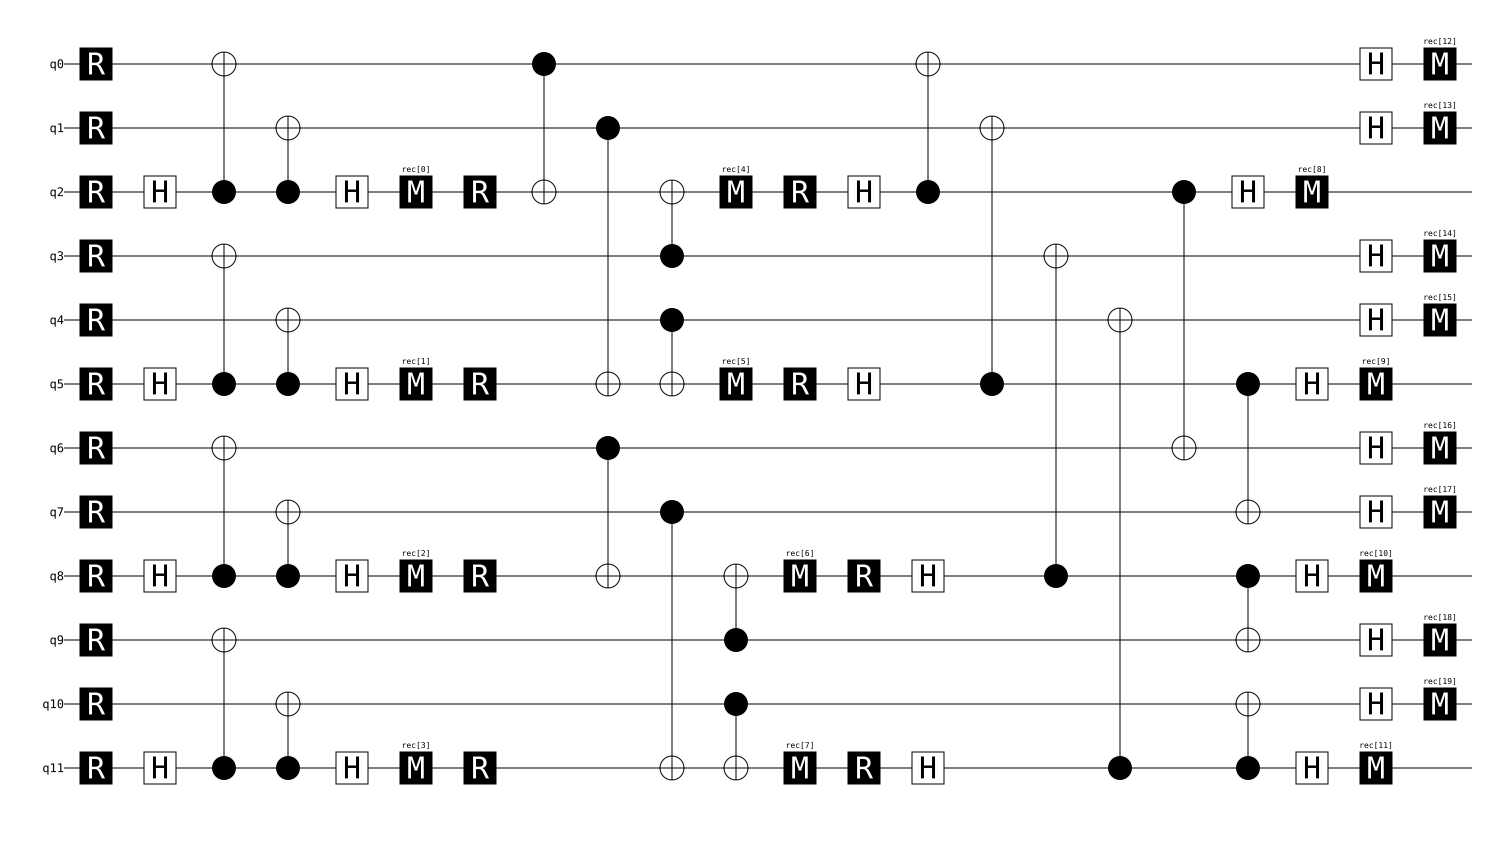

In [5]:
circuit.diagram("timeline-svg")

In [6]:
sampler = circuit.compile_sampler(seed=1)
results = sampler.sample(shots=int(1e4) )

res_bit_string = {}
for res in results:
    bit_string = ""
    for i in res:
        if i:
            bit_string = "1" + bit_string 
        else:
            bit_string = "0" + bit_string

    if bit_string in res_bit_string:
        res_bit_string[bit_string] = res_bit_string[bit_string] + 1
    else:
        res_bit_string[bit_string] = 1

n = 3
lstate = "X"
get_logical_error_on_accepted_states(n, lstate, res_bit_string)


(10000, 0, 0, 1.0, 0.4405229240001063, 0.08270756500132848)

### Noisy

In [7]:
def add_stim_error(circuit: stim.Circuit, p_error):
    noisy_circuit = stim.Circuit()

    for ins in circuit:
        used_qubits = []
        idle_qubits = []

        if ins.name != "M":
            noisy_circuit.append(ins)
        
        # TICK doesn't have an error
        if ins.name == "TICK":
            continue
        
        if ins.name == "H":
            noisy_circuit.append("X_ERROR", ins.targets_copy(), p_error)
        elif ins.name == "CX":
            noisy_circuit.append("DEPOLARIZE2", ins.targets_copy(), p_error)
        elif ins.name == "M":
            noisy_circuit.append("X_ERROR", ins.targets_copy(), p_error)
        elif ins.name == "R":
            noisy_circuit.append("X_ERROR", ins.targets_copy(), p_error)

        for qt in ins.targets_copy():
            used_qubits.append(qt.value)

        for i in range(circuit.num_qubits):
            if i not in used_qubits:
                idle_qubits.append(stim.GateTarget(i))

        if ins.name == "M":
            noisy_circuit.append(ins)
        
        if len(idle_qubits) > 1:
            noisy_circuit.append("DEPOLARIZE1", idle_qubits, p_error)    

    return noisy_circuit

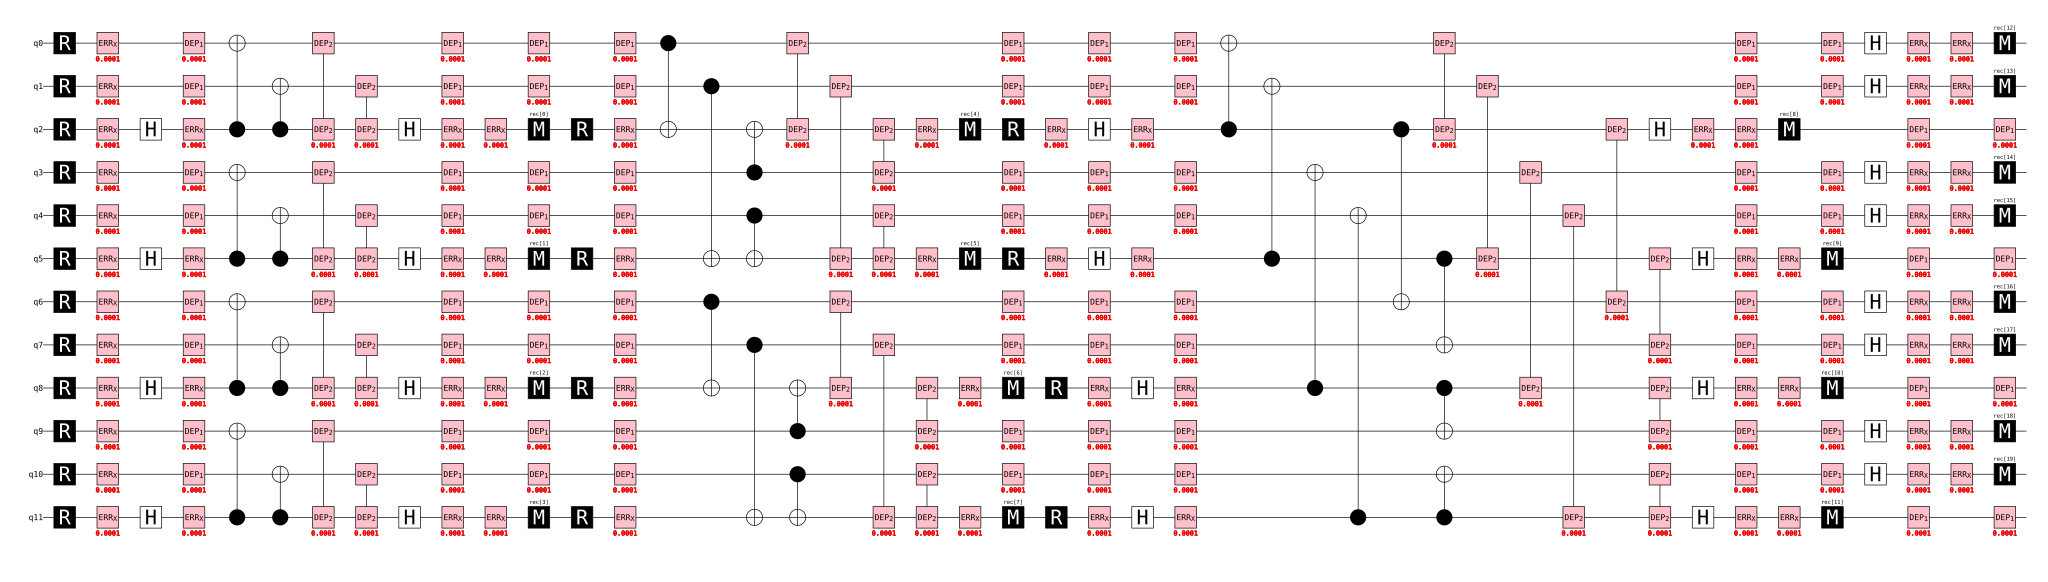

In [8]:
noisy_circuit = add_stim_error(circuit, 0.0001)
noisy_circuit.diagram("timeline-svg")


In [9]:
sampler = noisy_circuit.compile_sampler(seed=1)
results = sampler.sample(shots=int(1e4) )

res_bit_string = {}
for res in results:
    bit_string = ""
    for i in res:
        if i:
            bit_string = "1" + bit_string 
        else:
            bit_string = "0" + bit_string

    if bit_string in res_bit_string:
        res_bit_string[bit_string] = res_bit_string[bit_string] + 1
    else:
        res_bit_string[bit_string] = 1

n = 3
lstate = "X"
get_logical_error_on_accepted_states(n, lstate, res_bit_string)


(9886, 10, 21, 0.9989884685413717, 0.39212571600364754, 0.17026109300059034)

## Put into Function

In [10]:
# the code has been moved to stim_wrapper.py

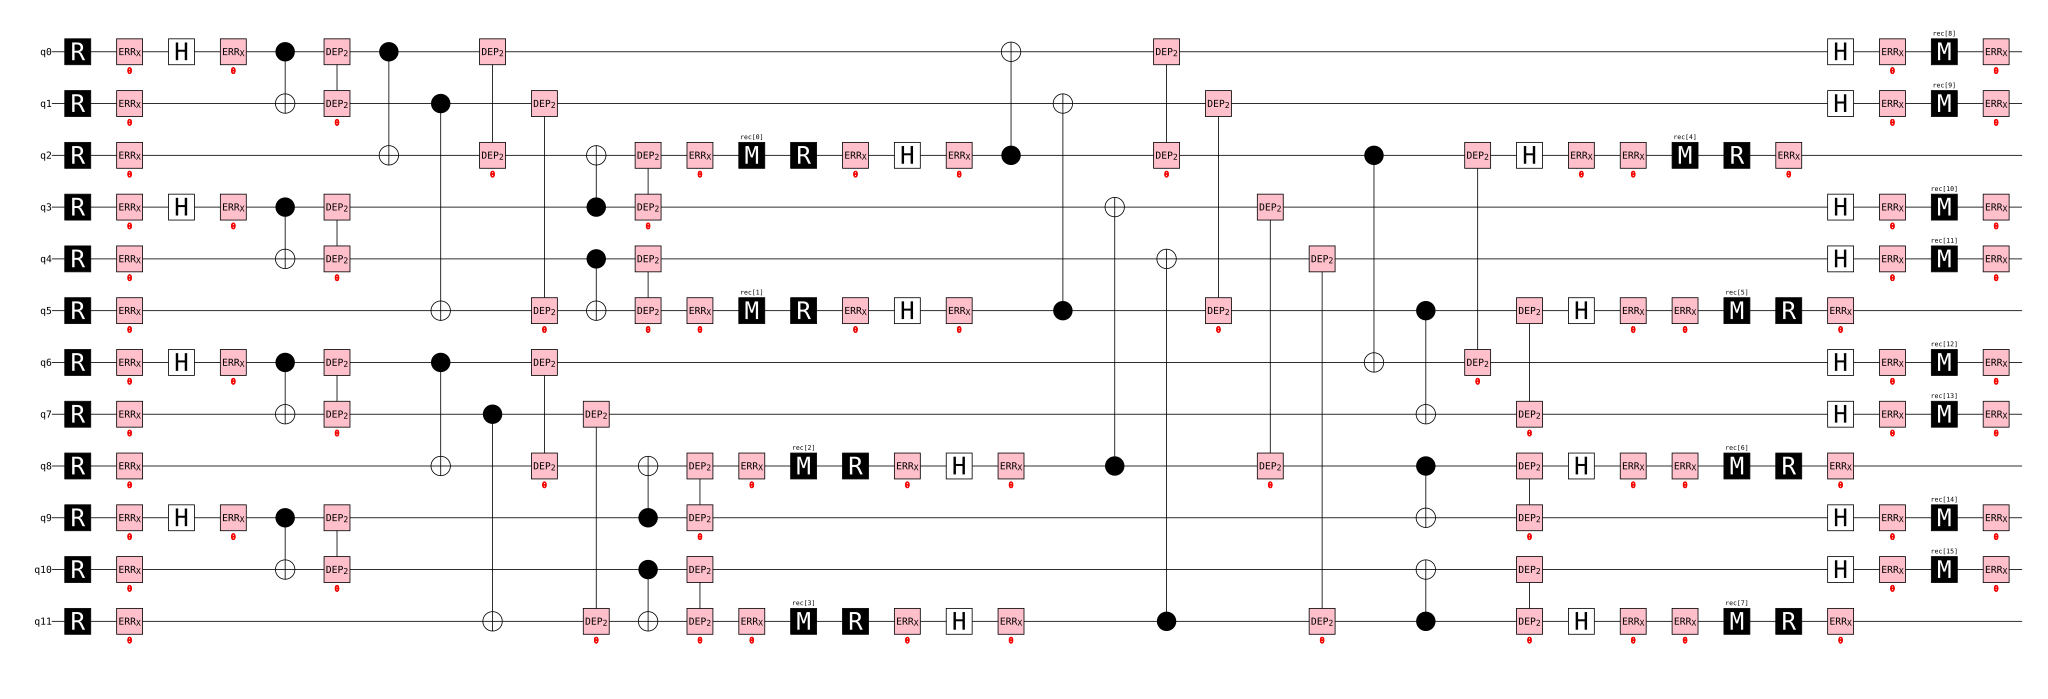

In [11]:
n = 3
i = 4
lstate = "X"
sim_type = "m1"
p_error = 0
shots = int(1e4)
seed = 1

N = 2**(n)
ancilla_qubits = 2**(n - 1)
total_qubits = N + ancilla_qubits

polar_n3 = create_circuit_polar_stim_normal(n, lstate, sim_type, p_error, seed, shots, None, None, None, ["x", "z", "x"], total_qubits, 0)
polar_n3.diagram("timeline-svg")



qiskit_runtime_service._discover_account:WARNING:2025-10-24 17:32:39,023: Loading account with the given token. A saved account will not be used.
/Users/handy/Github/quantum_platform/wrappers/stim_wrapper/stim_wrapper.py:723: UserWarning: Providing `coupling_map` and/or `basis_gates` along with `backend` is not recommended, as this will invalidate the backend's gate durations and error rates.
  pm = generate_preset_pass_manager(


ibm_torino 9623827 [4, 5, 1, 2, 3, 6, 15, 0, 19, 21, 22, 16]


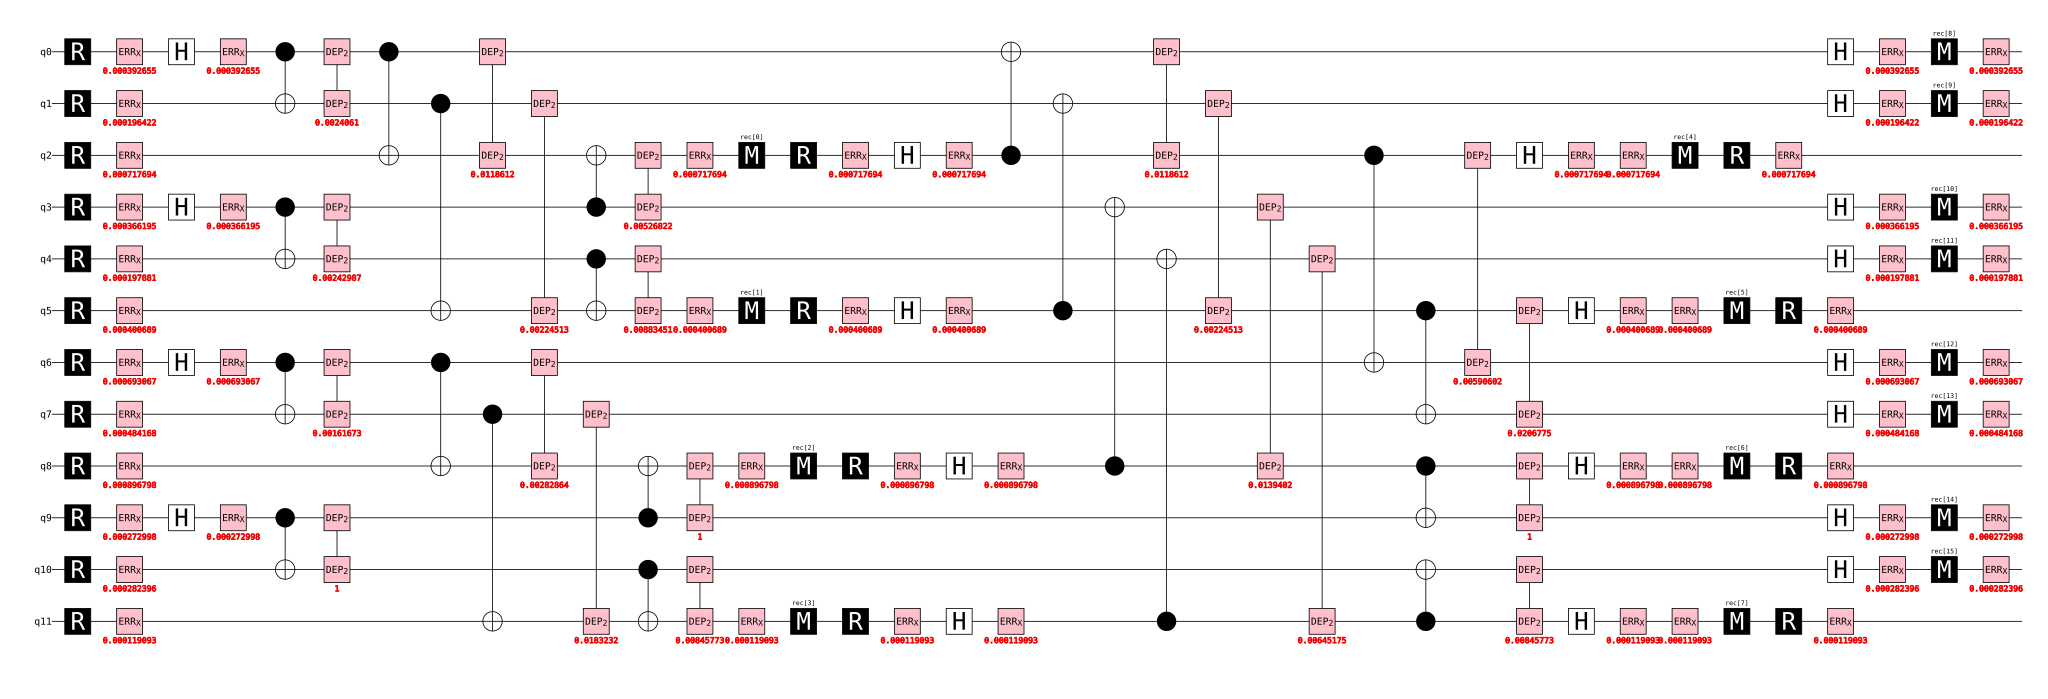

In [12]:
token = "23OwipXqZzd8plKZR2LDMK-peWuU74UQAyjAhMIaFHCM"
QiskitRuntimeService.save_account(channel="ibm_quantum_platform", token=token, instance="free", overwrite=True)
service = QiskitRuntimeService(channel="ibm_quantum_platform", token=token, instance="free")
hw_name = "ibm_torino"
seed_transpiler = random.randint(1, 9999999)

n = 3
i = 2
lstate = "X"
p_error = 1
shots = int(1e5)
seed = 2

backend = service.backend(hw_name)
qc = generate_qiskit_polar_code(n, lstate, sim_type, i)
tqc = compiled_to_qiskit_hardware(qc, backend, 3, seed_transpiler)
initial_layout = tqc.layout.initial_index_layout(filter_ancillas=True)
print(hw_name, seed_transpiler, initial_layout)

t1, t2, error_1q, readout_error, error_2q = get_backend_information(backend)
cm = backend.coupling_map

polar_n3 = create_circuit_polar_stim_normal(n, lstate, sim_type, p_error, seed, shots, error_1q, readout_error, error_2q, ["x", "z", "x"], total_qubits, 0, 
                                            cm = cm, initial_layout = initial_layout)
polar_n3.diagram("timeline-svg")

In [13]:
# function to simulate has been moved to stim_wrapper.py

#### Uniform error rate

In [14]:
n = 4
i = 2
lstate = "X"
p_error = 0.01
shots = int(1e3)
seed = 2

zpos_list = [-1, -1, 1, 3, 6, 7, 22, 15, 90, 31, 362]
zpos_list[n] = i-1

sim_type = "normal"
counts = simulate_stim_polar_code_normal(n, lstate, sim_type, i, p_error, shots, seed, backend = None, initial_layout = None)
count_accept_p, count_logerror, count_undecided, ler_p, detect_normal, decoding_normal = get_logical_error_on_accepted_states(n, lstate, counts, zpos_list=zpos_list)
print(count_accept_p, count_accept_p / shots, 1 - ler_p, count_logerror, count_undecided,)

sim_type = "m1"
counts = simulate_stim_polar_code_normal(n, lstate, sim_type, i, p_error, shots, seed, backend = None, initial_layout = None)
count_accept_p, count_logerror, count_undecided, ler_p, detect_normal, decoding_normal = get_logical_error_on_accepted_states(n, lstate, counts, zpos_list=zpos_list)
print(count_accept_p, count_accept_p / shots, 1 - ler_p, count_logerror, count_undecided,)


254 0.254 0.0 0 0
316 0.316 0.0 0 0


#### Non-uniform error rate

In [15]:
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
def compiled_to_qiskit_hardware(qc, backend, optimization_level = 3, seed_transpiler = 12345):
    # Compile first to get the initial layout with the noise-aware
    pm = generate_preset_pass_manager(
        optimization_level=optimization_level, backend=backend,
        seed_transpiler=seed_transpiler)
    tqc = pm.run(qc)

    initial_layout = tqc.layout.initial_index_layout(filter_ancillas=True)
    # print(hw_name, seed_transpiler, initial_layout)

    basis_gates = backend.configuration().basis_gates
    if 'cx' not in basis_gates:
            basis_gates = basis_gates + ['cx']
            basis_gates = basis_gates + ['h']
            basis_gates = basis_gates + ['swap']

    pm = generate_preset_pass_manager(
            optimization_level=3, backend=backend,        
            seed_transpiler=seed_transpiler,
            initial_layout=initial_layout,
            basis_gates=basis_gates
            )
        
    tqc_new = pm.run(qc)

    return tqc_new

In [16]:
from qiskit.converters import circuit_to_dag, dag_to_circuit    

def compile_circuit_qiskit_to_stim(tqc, backend, p_error):
    dag = circuit_to_dag(tqc)
    circuit = stim.Circuit()
    m_order = []

    t1, t2, error_1q, readout_error, error_2q = get_backend_information(backend)

    for idx, layer in enumerate(dag.layers()):
        layer_as_circuit = dag_to_circuit(layer['graph']) 

        for g in layer_as_circuit:
            
            op = g.operation
            qbits = g.qubits
            cbits = g.clbits
            qb1 = qbits[0]._index
            # print(op, qbits, cbits, op)

            if op.num_qubits == 1:
                # print(op.name, op.num_qubits, qbits[0]._index)
                if op.name == "h":
                    error_rate = error_1q[qb1] * p_error

                    circuit.append(op.name, qb1)
                    circuit.append("DEPOLARIZE1", qb1, error_rate)
                    
                elif op.name == "reset":
                    error_rate = error_1q[qb1] * p_error

                    circuit.append("r", qb1)
                    circuit.append("X_ERROR", qb1, error_rate)

                elif op.name == "measure":
                    error_rate = readout_error[qb1] * p_error

                    circuit.append("X_ERROR", qb1, error_rate)
                    circuit.append("m", qb1)
                    
                    m_order.append(cbits[0]._index)
                    # print(g)
                    
            else:
                qb2 = qbits[1]._index
                error_rate = error_2q[(qb1, qb2)] * p_error

                if op.name == "cx":
                    circuit.append(op.name, [qb1, qb2])
                    circuit.append("DEPOLARIZE2", [qb1, qb2], error_rate)
                elif op.name == "swap":
                    circuit.append("cx", [qb1, qb2])
                    circuit.append("DEPOLARIZE2", [qb1, qb2], error_rate)
                    circuit.append("cx", [qb2, qb1])
                    circuit.append("DEPOLARIZE2", [qb1, qb2], error_rate)
                    circuit.append("cx", [qb1, qb2])
                    circuit.append("DEPOLARIZE2", [qb1, qb2], error_rate)

    return circuit, m_order
                    
    



In [ ]:
test = [4, 5, 6]
test.

In [ ]:
def create_circuit_polar_stim_from_qiskit(n, lstate, sim_type, p_error, seed, backend
                            ):

    circuit = stim.Circuit()

    qc = generate_qiskit_polar_code(n, lstate.lower(), sim_type, i)
    tqc = compiled_to_qiskit_hardware(qc, backend, 3, seed)

    circuit, m_order = compile_circuit_qiskit_to_stim(tqc, backend, p_error)
    
    new_m_order = []
    if sim_type in ["m1", "m2"]:
        for i in range(2**(n - 1)):
            new_m_order.append(i)

        for i in m_order:
            new_m_order.append(i)
    else:
        new_m_order = m_order

    return circuit, new_m_order

IndentationError: expected an indented block after 'for' statement on line 11 (700985441.py, line 14)

In [ ]:
def simulate_stim_polar_code_normal_from_qiskit_circuit(n, lstate, sim_type, i, p_error, shots, seed, backend):
    """
    Simulates a quantum circuit for stabilizer code, simplified and optimized.

    Args:
        n (int): code length for polar code
        lstate (str): z for logical |0>, z for logical |+>
        sim_type: normal, m1, m2, m3
        p_error (float): The probability of an error occurring.
        shots (int): The number of simulation runs.
        seeds (list): A list of seeds for the simulator.
        i (int): An index used to determine measurement types (message location)

    Returns:
        dict: A dictionary of measurement outcome counts.
    """
    #m1 circuit simplify
    #m2 m1 + error detection
    #m3 m1 + error correction
    
    meas_type = convert_i_to_meas_type(i, n, lstate)
    N = 2**n
    ancilla_qubits = 2**(n - 1)
    total_qubits = N + ancilla_qubits

    x_ind = 0
    for idx, m_type in enumerate(meas_type):
        if m_type == "x":
            x_ind = idx
            break

    circuit, m_order = create_circuit_polar_stim_from_qiskit(n, lstate, sim_type, p_error, seed, backend)
    
    sampler = circuit.compile_sampler(seed=seed)
    results = sampler.sample(shots=int(shots) )

    res_bit_string = {}
    for res in results:
        bit_string = ""

        if sim_type in ["m1", "m2"]:
            bit_string = bit_string + "0"*(2**(n - 1))

        for i in res:
            if i:
                bit_string = bit_string + "1" 
            else:
                bit_string = bit_string + "0"

        # print(len(bit_string), bit_string, m_order)

        new_bits = [''] * len(bit_string)

        # Loop through each bit in the original string
        for i in range(len(bit_string)):
            # Get the bit from the original string
            original_bit = bit_string[i]
            
            # Get the new position for this bit from the order list
            new_position = m_order[i]
            
            # Place the bit in its new position
            new_bits[new_position] = original_bit

        reordered_string = "".join(new_bits)[::-1]


        if reordered_string in res_bit_string:
            res_bit_string[reordered_string] = res_bit_string[reordered_string] + 1
        else:
            res_bit_string[reordered_string] = 1

    return res_bit_string

In [19]:
token = "23OwipXqZzd8plKZR2LDMK-peWuU74UQAyjAhMIaFHCM"
QiskitRuntimeService.save_account(channel="ibm_quantum_platform", token=token, instance="free", overwrite=True)
service = QiskitRuntimeService(channel="ibm_quantum_platform", token=token, instance="free")
hw_name = "ibm_torino"
backend = service.backend(hw_name)

qiskit_runtime_service._discover_account:WARNING:2025-10-24 17:32:44,675: Loading account with the given token. A saved account will not be used.


In [20]:
# t1, t2, error_1q, readout_error, error_2q = get_backend_information(backend)

# sim_ideal = AerSimulator()
# sim_noisy = AerSimulator.from_backend(backend)

# noise_model = NoiseModel.from_backend(backend)
# noise_model.add_basis_gates("cx")
# for key, value in error_2q.items():
#     dep_error_2q = depolarizing_error(value, 2)
#     noise_model.add_quantum_error(dep_error_2q, "cx", key )

# noise_model.add_basis_gates("h")
# for key, value in error_1q.items():
#     dep_error_1q = depolarizing_error(value, 1)
#     noise_model.add_quantum_error(dep_error_1q, "h", (key,) )

# properties = backend.properties()
# prop_dict = properties.to_dict()
# new_prop_dict = properties.to_dict().copy()

# for i in prop_dict["gates"]:
#     if(i["gate"] == "cz"):
#         gate_dict = copy.deepcopy(i)
#         gate_dict["gate"] = "cx"

#         new_prop_dict["gates"].append(gate_dict)
        
#     if(i["gate"] == "x"):
#         gate_dict = copy.deepcopy(i)
#         gate_dict["gate"] = "h"

#         new_prop_dict["gates"].append(gate_dict)

# new_prop = properties.from_dict(new_prop_dict)

# sim_noisy_cx = AerSimulator(# configuration=backend.configuration(),
#                             properties=new_prop,
#                             # properties=backend.properties(),
#                             noise_model=noise_model)

In [26]:
hw_name = "ibm_torino"
seed_transpiler = random.randint(1, 9999999)
# seed_transpiler = 12345

n = 3
i = 2
lstate = "X"
p_error = 0.01
shots = int(1e4)
seed = 2
sim_type = "m1"

backend = service.backend(hw_name)
qc = generate_qiskit_polar_code(n, lstate.lower(), sim_type, i)
tqc = compiled_to_qiskit_hardware(qc, backend, 3, seed_transpiler)
tqc.draw(fold=-1, idle_wires=False)

/var/folders/v6/623nkjns6rs5jqzt737r741m0000gn/T/ipykernel_94292/952868055.py:18: UserWarning: Providing `coupling_map` and/or `basis_gates` along with `backend` is not recommended, as this will invalidate the backend's gate durations and error rates.
  pm = generate_preset_pass_manager(


┌───┐                                                                                                                                    
       q_0 -> 25 ─|0>─┤ H ├──■──────X──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
                      └───┘┌─┴─┐    │                                                                                                                          
       q_1 -> 26 ─|0>──────┤ X ├─X──┼──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
                           └───┘ │  │ ┌───┐                                                      ┌───┐┌───┐                           ┌─┐                      
ancilla_25 -> 27 ────────────────X──┼─┤ X ├──────────────────────────────────────────────────────┤ X ├┤ H ├───────────────────────────┤M├──────────────────────
                      ┌───┐         │ └─┬─┘                                                      └─┬─┘└───┘┌───┐                      └╥┘      ┌─┐             
       q_5 -> 28 ─|0>─┤ H ├─────────┼───■────────X────────────────────────────────────────────X────■────■──┤ H ├───────────────────────╫───────┤M├─|0>─────────
                      └───┘┌───┐    │      ┌───┐ │      ┌───┐                  ┌─┐     ┌───┐  │       ┌─┴─┐├───┤                       ║       └╥┘     ┌─┐     
       q_7 -> 29 ─|0>──────┤ X ├────┼──────┤ X ├─X───■──┤ H ├──────────────────┤M├─|0>─┤ H ├──X───────┤ X ├┤ H ├───────────────────────╫────────╫──────┤M├─────
                           └─┬─┘    │ ┌───┐└─┬─┘     │  └───┘                  └╥┘     ├───┤┌───┐     └───┘└───┘┌─┐                    ║        ║      └╥┘     
ancilla_31 -> 35 ────────────┼──────X─┤ X ├──┼───────┼──────────────────────────╫──────┤ X ├┤ H ├───────────────┤M├────────────────────╫────────╫───────╫──────
                      ┌───┐  │        └─┬─┘  │     ┌─┴─┐                        ║      └─┬─┘└───┘┌───┐┌───┐     └╥┘        ┌─┐         ║        ║       ║      
       q_6 -> 36 ─|0>─┤ H ├──■──────X───┼────■───X─┤ X ├────────────────────────╫────────┼───────┤ X ├┤ H ├──────╫─────────┤M├─────────╫────────╫───────╫──────
                      ├───┤         │   │        │ ├───┤               ┌─┐      ║ ┌───┐  │       └─┬─┘├───┤      ║      ┌─┐└╥┘         ║        ║       ║      
       q_2 -> 44 ─|0>─┤ H ├─────────┼───■────■───┼─┤ H ├───────────────┤M├─|0>──╫─┤ H ├──■────■────┼──┤ H ├──────╫──────┤M├─╫──|0>─────╫────────╫───────╫──────
                      └───┘         │      ┌─┴─┐ │ └───┘               └╥┘      ║ └───┘     ┌─┴─┐  │  ├───┤      ║      └╥┘ ║  ┌─┐     ║        ║       ║      
      q_10 -> 45 ─|0>────────────X──┼──────┤ X ├─┼──────────────────X───╫───────╫───────────┤ X ├──┼──┤ H ├──────╫───────╫──╫──┤M├─────╫────────╫───────╫──────
                      ┌───┐      │  │      ├───┤ │           ┌───┐  │   ║       ║           └───┘  │  ├───┤┌───┐ ║       ║  ║  └╥┘     ║ ┌─┐    ║       ║      
       q_3 -> 46 ─|0>─┤ H ├──■───X──┼──────┤ X ├─┼───X───────┤ X ├──X───╫───────╫──────────────────┼──┤ X ├┤ H ├─╫───────╫──╫───╫──────╫─┤M├────╫───────╫──────
                      └───┘┌─┴─┐    │      └─┬─┘ │   │  ┌───┐└─┬─┘      ║       ║                  │  └─┬─┘├───┤ ║ ┌───┐ ║  ║   ║      ║ └╥┘┌─┐ ║       ║      
       q_4 -> 47 ─|0>──────┤ X ├────┼───X────┼───┼───X──┤ X ├──┼────────╫───────╫──────────────────┼────┼──┤ X ├─╫─┤ H ├─╫──╫───╫──────╫──╫─┤M├─╫───────╫──────
                      ┌───┐└───┘    │   │    │   │      └─┬─┘  │  ┌───┐ ║       ║  ┌─┐      ┌───┐  │    │  └─┬─┘ ║ ├───┤ ║  ║   ║  ┌─┐ ║  ║ └╥┘ ║       ║      
      q_11 -> 48 ─|0>─┤ H ├─────────X───X────┼───X────────■────┼──┤ H ├─╫───────╫──┤M├──|0>─┤ H ├──■────┼────■───╫─┤ H ├─╫──╫───╫──┤M├─╫──╫──╫──╫──|0>──╫──────
                      ├───┤                  │                 │  └───┘ ║ ┌───┐ ║  └╥┘  ┌─┐ └───┘┌───┐  │        ║ ├───┤ ║  ║   ║  └╥┘ ║  ║  ║  ║  ┌─┐  ║      
       q_9 -> 55 ─|0>─

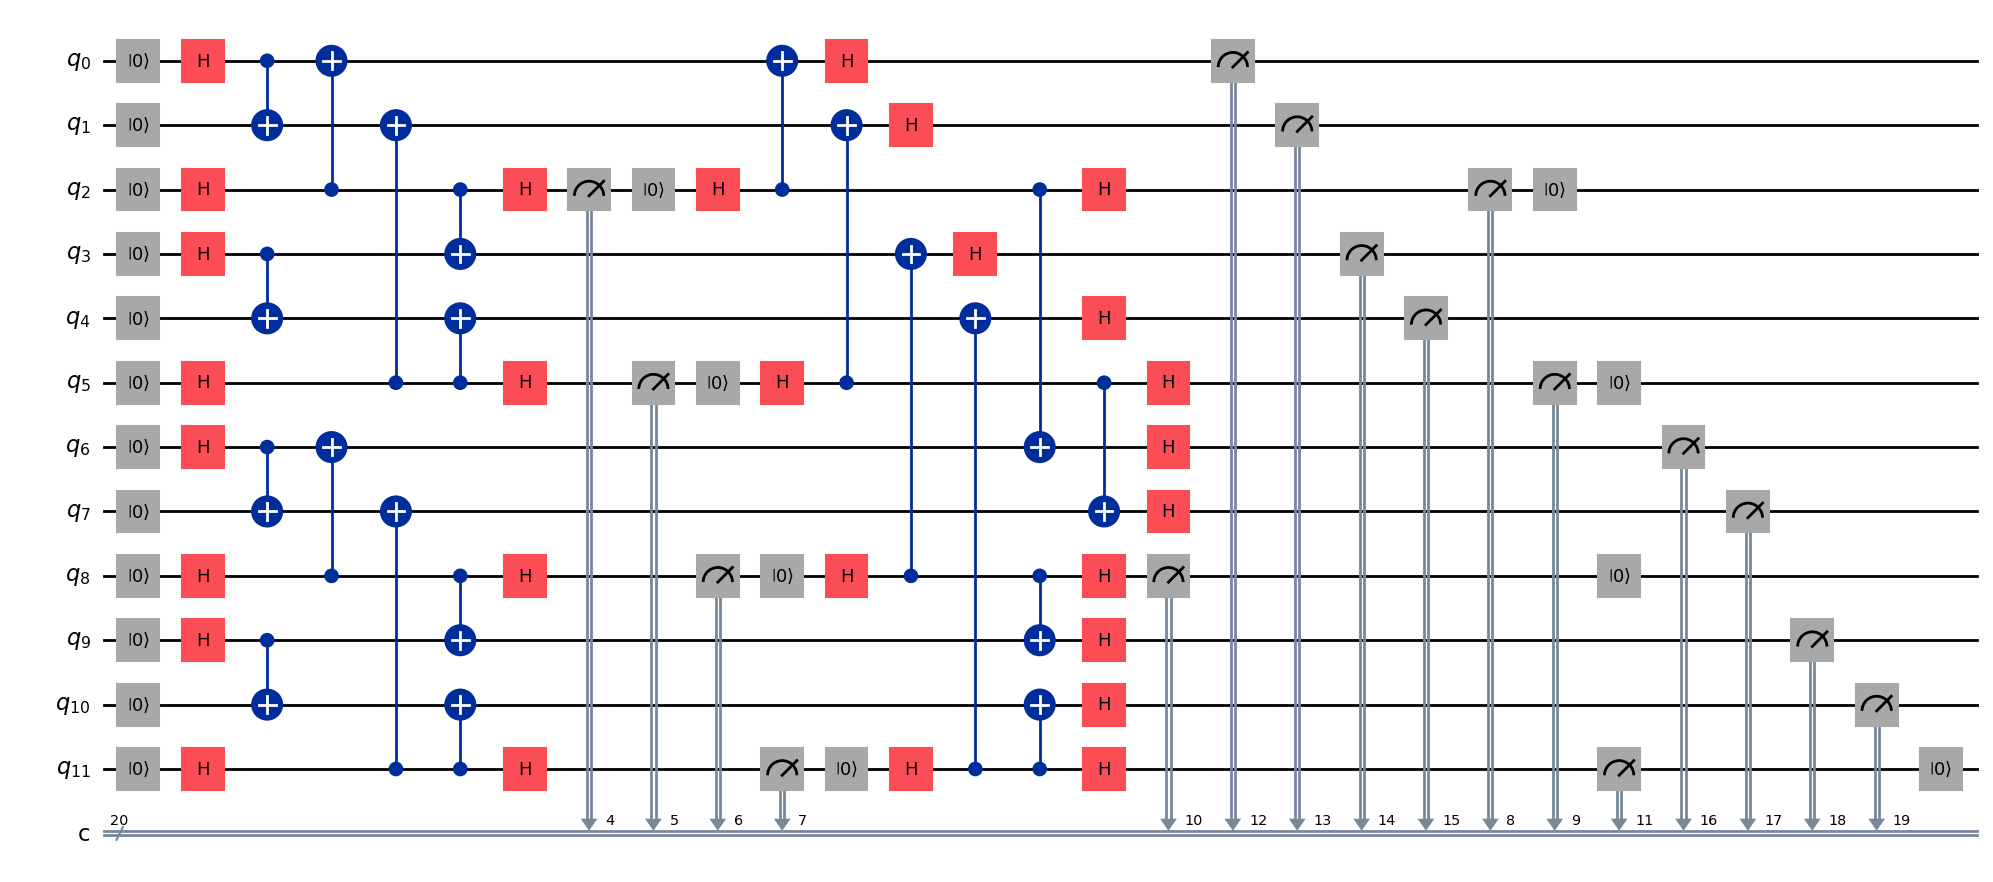

In [27]:
qc.draw("mpl", fold=-1)

##### Converting from Qiskit Layout to STIM

[4, 5, 7, 6, 12, 8, 15, 16, 11, 13, 14, 19, 9, 10, 17, 18]


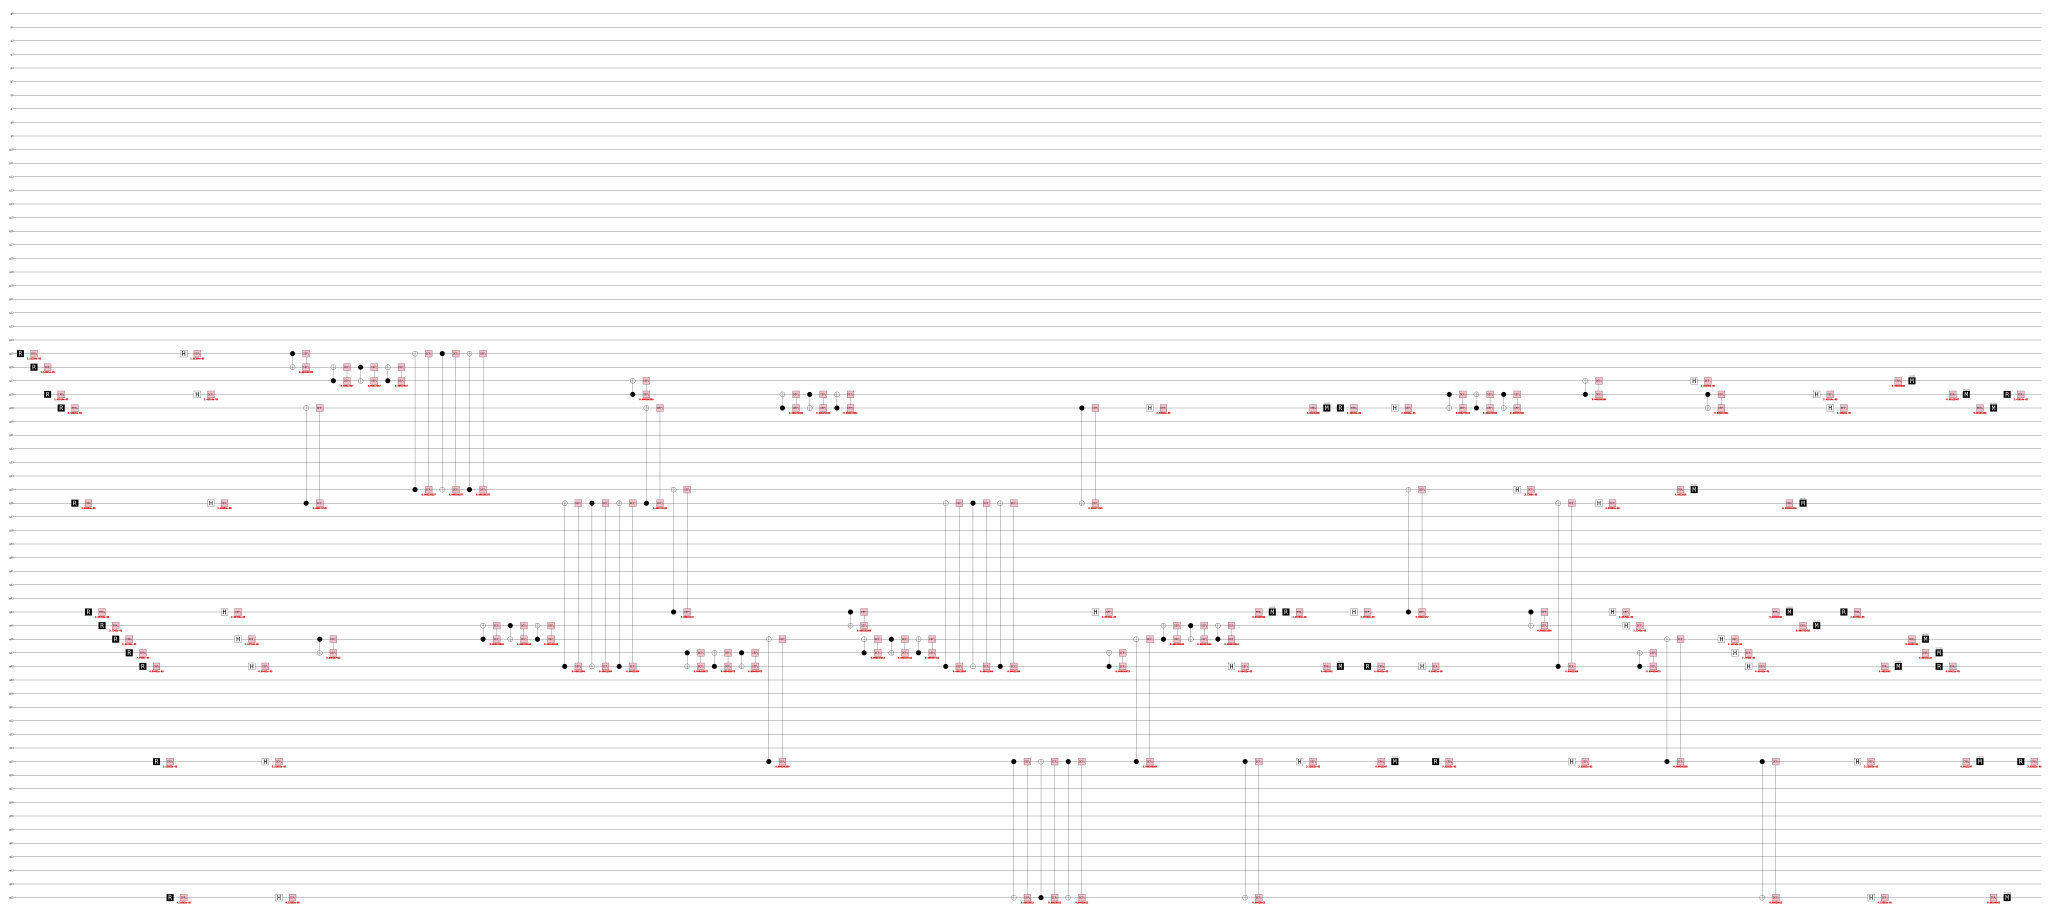

In [28]:
circuit, m_order = compile_circuit_qiskit_to_stim(tqc, backend, 0.1)
print(m_order)
circuit.diagram("timeline-svg")

In [24]:
# # print(m_order)
# sampler = circuit.compile_sampler(seed=1)
# results = sampler.sample(shots=int(1e5) )

# res_bit_string = {}
# for res in results:
#     bit_string = ""
#     for i in res:
#         if i:
#             bit_string = bit_string + "1" 
#         else:
#             bit_string = bit_string + "0"

#     # Create a new list to hold the reordered bits
#     # Initialize it with placeholders (e.g., empty strings)
#     new_bits = [''] * len(bit_string)

#     # Loop through each bit in the original string
#     for i in range(len(bit_string)):
#         # Get the bit from the original string
#         original_bit = bit_string[i]
        
#         # Get the new position for this bit from the order list
#         new_position = m_order[i]
        
#         # Place the bit in its new position
#         new_bits[new_position] = original_bit

#     # Join the list of bits back into a single string
#     reordered_string = "".join(new_bits)[::-1]

#     bit_string = bit_string[::-1]

#     # print(f"Original bitstring:  {bit_string}")
#     # print(f"Reordered bitstring: {reordered_string}")

#     if reordered_string in res_bit_string:
#         res_bit_string[reordered_string] = res_bit_string[reordered_string] + 1
#     else:
#         res_bit_string[reordered_string] = 1

# n = 3
# lstate = "X"
# i = 2
# zpos_list = [-1, -1, 1, i-1, 6, 7, 22, 15, 90, 31, 362]
# get_logical_error_on_accepted_states(n, lstate, res_bit_string, zpos_list)


In [25]:
n = 4
i = 2
lstate = "X"
p_error = 0
shots = int(1e4)
seed = random.randint(1, 9999999)
# seed = 2

hw_name = "ibm_torino"
backend = service.backend(hw_name)

zpos_list = [-1, -1, 1, 3, 6, 7, 22, 15, 90, 31, 362]
zpos_list[n] = i-1

sim_type = "normal"
counts = simulate_stim_polar_code_normal_from_qiskit_circuit(n, lstate, sim_type, i, p_error, shots, seed, backend)
count_accept_p, count_logerror, count_undecided, ler_p, detect_normal, decoding_normal = get_logical_error_on_accepted_states(n, lstate, counts, zpos_list=zpos_list)
print(count_accept_p, count_accept_p / shots, 1 - ler_p, count_logerror, count_undecided,)

sim_type = "m1"
counts = simulate_stim_polar_code_normal_from_qiskit_circuit(n, lstate, sim_type, i, p_error, shots, seed, backend)
count_accept_p, count_logerror, count_undecided, ler_p, detect_normal, decoding_normal = get_logical_error_on_accepted_states(n, lstate, counts, zpos_list=zpos_list)
print(count_accept_p, count_accept_p / shots, 1 - ler_p, count_logerror, count_undecided,)


/var/folders/v6/623nkjns6rs5jqzt737r741m0000gn/T/ipykernel_94292/952868055.py:18: UserWarning: Providing `coupling_map` and/or `basis_gates` along with `backend` is not recommended, as this will invalidate the backend's gate durations and error rates.
  pm = generate_preset_pass_manager(


48 100011101000001100001110111001010000110001101011 [0, 1, 2, 4, 7, 6, 8, 9, 10, 12, 3, 15, 14, 20, 16, 5, 22, 36, 28, 44, 18, 13, 32, 23, 21, 30, 38, 34, 46, 11, 17, 24, 40, 26, 42, 37, 29, 45, 25, 33, 41, 19, 39, 31, 47, 35, 27, 43]
48 101011101100010101100010000000001000111010011011 [0, 1, 2, 4, 7, 6, 8, 9, 10, 12, 3, 15, 14, 20, 16, 5, 22, 36, 28, 44, 18, 13, 32, 23, 21, 30, 38, 34, 46, 11, 17, 24, 40, 26, 42, 37, 29, 45, 25, 33, 41, 19, 39, 31, 47, 35, 27, 43]
48 000100111000010111010010010011010001010110011011 [0, 1, 2, 4, 7, 6, 8, 9, 10, 12, 3, 15, 14, 20, 16, 5, 22, 36, 28, 44, 18, 13, 32, 23, 21, 30, 38, 34, 46, 11, 17, 24, 40, 26, 42, 37, 29, 45, 25, 33, 41, 19, 39, 31, 47, 35, 27, 43]
48 110100001011101111010000100000011111011100110110 [0, 1, 2, 4, 7, 6, 8, 9, 10, 12, 3, 15, 14, 20, 16, 5, 22, 36, 28, 44, 18, 13, 32, 23, 21, 30, 38, 34, 46, 11, 17, 24, 40, 26, 42, 37, 29, 45, 25, 33, 41, 19, 39, 31, 47, 35, 27, 43]
48 110110111101011000001011011001001000000000101110 [0, 1, 2

IndexError: list index out of range